In [1]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
trace_num = 500
order = '4'
opt = 'o3' # o0 or o3
scope = '' # _chipwhisperer or space
algo = 'PQClean' # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4' # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

trace_path = f'traces{scope}/{trace_num}_3/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'

t = np.load(f'{trace_path}/trace.npy')
l = np.load(f'{trace_path}/message.npy')

snr_path = f'traces_train/best_traces/traces_unfixed_message_2000_picoscope_CW308_STM32F4_o3_PQClean_poi'
snr = np.load(f'{snr_path}/snr.npy')

In [3]:
print("Size of Trace: ", end="")
print(t.shape)
print(t)
print("\nSize of Message: ", end="")
print(l.shape)
print(l)

Size of Trace: (500, 455000)
[[-0.00247528 -0.00101636  0.00044256 ...  0.00767611  0.00691308
   0.00513674]
 [-0.00247528 -0.00076303  0.00044256 ...  0.0072305   0.00596081
   0.00424857]
 [-0.0027286  -0.00146197  0.00012514 ...  0.00735869  0.00761201
   0.00634233]
 ...
 [-0.00190453 -0.00025638  0.00101331 ...  0.00691308  0.00577158
   0.00437675]
 [-0.00203272 -0.00044561  0.00069589 ...  0.00317116  0.00253632
   0.00304297]
 [-0.00266756 -0.00133378  0.00018923 ...  0.00748382  0.00697717
   0.00551825]]

Size of Message: (500, 32)
[[126. 198.  37. ... 157.  29. 180.]
 [ 12.  74.  50. ... 199. 250.   4.]
 [ 86.  74. 210. ... 186. 126.  19.]
 ...
 [ 70.  51. 175. ...   4. 167. 111.]
 [107.  86. 104. ... 155.  69. 115.]
 [149.   9.  33. ... 127. 125.  21.]]


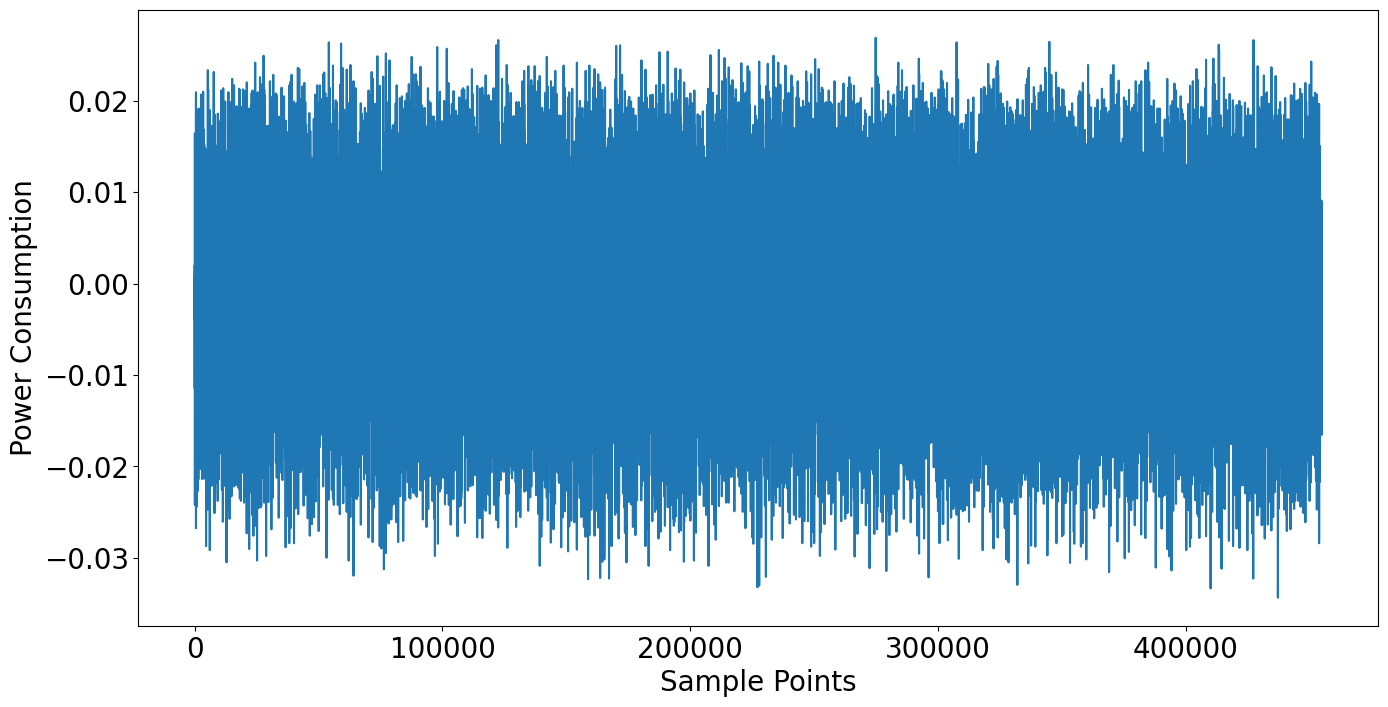

In [4]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t[0])

In [5]:
mean_t = np.mean(t, axis=0)
print(mean_t)

[-0.00240935 -0.00105127  0.00025623 ...  0.00656549  0.00611378
  0.00503918]


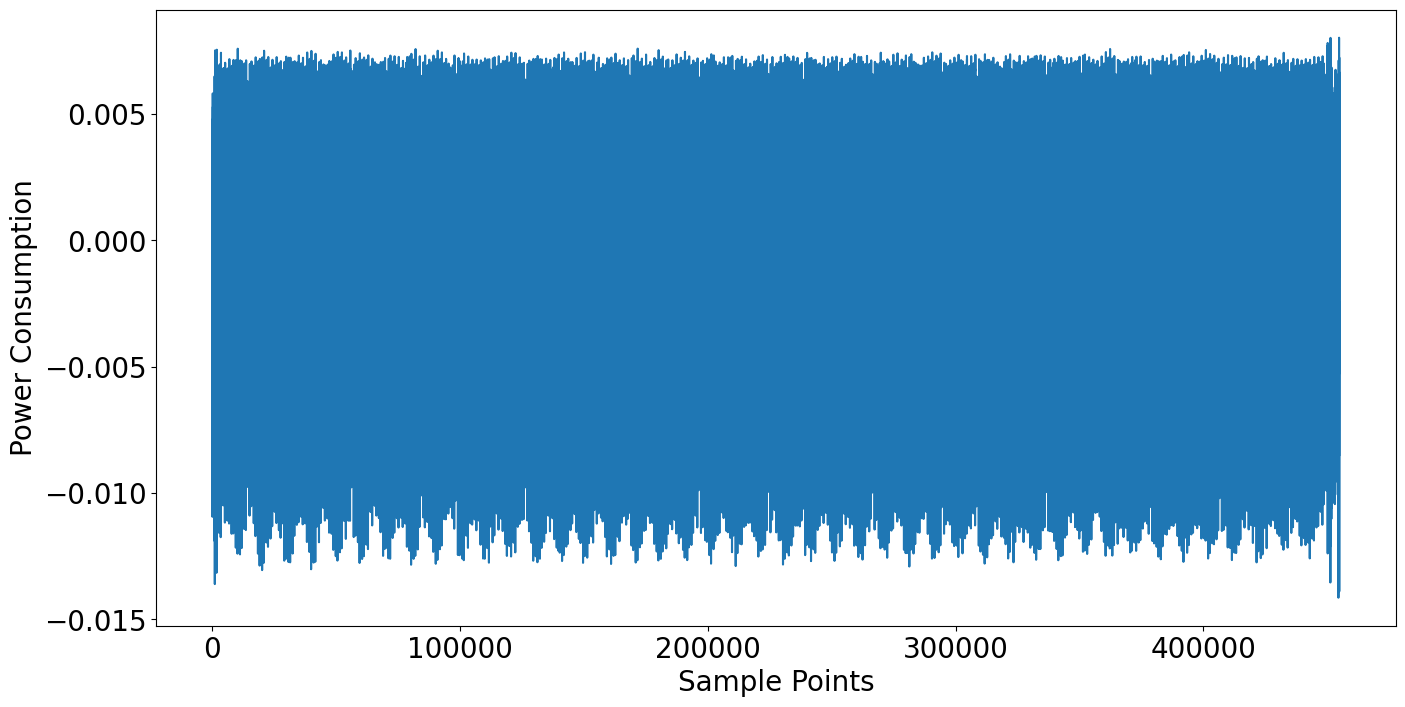

In [6]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(mean_t)

In [7]:
trace_length = t.shape[1]
print(trace_length)

455000


In [8]:
print(snr)

[  1694   3387   5079   6891   8583  10308  12106  13799  15964  17657
  19349  21044  22737  24430  26121  27813  29981  31675  33367  35060
  36753  38445  40138  41829  43998  45691  47383  49077  50770  52462
  54155  55848  58014  59707  61400  63093  64784  66478  68171  69862
  72030  73723  75417  77108  78801  80494  82187  83880  86047  87739
  89433  91125  92817  94510  96203  97897 100064 101756 103448 105140
 106834 108528 110218 111911 114079 115772 117464 119158 120851 122543
 124237 125929 128095 129788 131480 133175 134865 136559 138251 139944
 142112 143805 145497 147191 148882 150576 152269 153963 156128 157821
 159512 161207 162899 164592 166285 167978 170145 171838 173530 175223
 176915 178608 180301 181993 184161 185853 187546 189240 190933 192625
 194318 196010 198178 199870 201564 203255 204948 206641 208333 210027
 212194 213886 215579 217271 218963 220658 222356 224043 226210 227902
 229595 231288 232982 234673 236366 238059 240224 241918 243618 245304
 24699

In [9]:
import numpy as np

# ---------- 已知參數 ----------
trace_num = t.shape[0]           # trace 总数
L         = t.shape[1]         # 每条 trace 的长度
N_POI     = 256            # 总共 256 个 POI
N_BYTE    = 32             # 分成 32 个 byte（每 byte 下有 8 个 POI）
POI_PER_BYTE = 8           # 每组 8 个 POI

WIN = 300                  # 每个 POI 要取 ±300 样点
WIN_SIZE = 2 * WIN + 1     # = 601

# 假设 snr_idx 是一个长度为 256 的 numpy 数组，
# 里面存放了每个 POI 在 trace 中的全局索引
# 比如：snr_idx = np.array([... 256 个整数 ...])
snr_idx = np.asarray(snr)   # 你之前计算出的 256 个 POI 全局索引

# t 的形状应该是 (2000, 455000)，l 的形状是 (2000, 32)
# t[tr] 表示第 tr 条 trace；l[tr, byte] 是第 tr 条 trace 下第 byte 的标签（一个 0~255 的值）

# ---------- 步骤 1：先从每条 trace 上针对所有 256 个 POI，截取 ±300 采样点窗口 ----------
# 我们把它放到一个中间数组 W，形状 (trace_num, 256, 601)
W = np.zeros((trace_num, N_POI, WIN_SIZE), dtype=t.dtype)

for tr in range(trace_num):
    trace = t[tr]   # 长度 = L
    for p in range(N_POI):
        idx = int(snr_idx[p])
        start = idx - WIN
        end   = idx + WIN + 1   # Python slice 不包含 end，本质上拿到的元素数量 = WIN_SIZE
        
        window = trace[start : end]
        
        # 此时 window 应该总长度为 601
        if window.shape[0] != WIN_SIZE:
            raise ValueError(f"第 {tr} 条 trace，第 {p} 个 POI 切片后长度 = {window.shape[0]}，理应 = {WIN_SIZE}。")
        
        W[tr, p, :] = window
    # print(tr)

# ---------- 步骤 2：把 256 个 POI 分成 32 组（每组 8 个 POI），然后把同一条 trace 下的“8 个 601 向量”拼接成长度 4808 ----------

# 先准备一个索引列表，切分成 32 份
# 比如： group_indices[0] = [0,1,2,3,4,5,6,7]， group_indices[1] = [8..15]，…… 以此类推
group_indices = [ list(range(byte*POI_PER_BYTE, (byte+1)*POI_PER_BYTE)) for byte in range(N_BYTE) ]
# group_indices 长度 = 32，每个元素是一个长度为 8 的 Python list

# 定义 X_final 存最终结果
# 如果你想得到 (2000, 32, 4808)，就：
X_final = np.zeros((trace_num, N_BYTE, POI_PER_BYTE * WIN_SIZE), dtype=t.dtype)
# 对应的标签 y 形状： (trace_num, 32)
Y_label = np.zeros((trace_num, N_BYTE), dtype=l.dtype)

for tr in range(trace_num):
    for byte in range(N_BYTE):
        poi_list = group_indices[byte]  # 这是一组 8 个 POI 的下标
        # 从 W[tr, :, :] 中抽取这 8 个 POI 的 window，然后沿最后一维 concat
        windows_to_concat = [ W[tr, p, :] for p in poi_list ]   # 列表里装 8 个形状为 (601,) 的 array
        X_seg = np.concatenate(windows_to_concat, axis=0)        # 结果长度 = 8 × 601 = 4808
        
        # 放回 X_final
        X_final[tr, byte, :] = X_seg
        # 标签直接来源于原始 l
        Y_label[tr, byte]  = l[tr, byte]
    # print(tr)
# 最终：
#   X_final.shape = (2000, 32, 4808)
#   Y_label.shape = (2000, 32)

# 如果你要做「每个 byte 作为一次样本」的训练，就可以把它 reshape 成 (2000*32, 4808)，对应标签也展平成 (2000*32,)
X_flat = X_final.reshape(trace_num * N_BYTE, POI_PER_BYTE * WIN_SIZE)
Y_flat = Y_label.reshape(trace_num * N_BYTE)

print("X_flat.shape =", X_flat.shape)   # 应该是 (64000, 4808)
print("Y_flat.shape =", Y_flat.shape)   # 应该是 (64000,)


X_flat.shape = (16000, 4808)
Y_flat.shape = (16000,)


In [10]:
print('size of new_trace:', X_flat.shape)
print(X_flat[0])
print('size of new_label:', Y_flat.shape)
print(Y_flat[2])

size of new_trace: (16000, 4808)
[ 0.00348859  0.00437675  0.00393114 ... -0.01199182 -0.00907398
 -0.00475827]
size of new_label: (16000,)
37.0


In [11]:
print(t[0, 1394:1394+3])

[0.00348859 0.00437675 0.00393114]


#### check

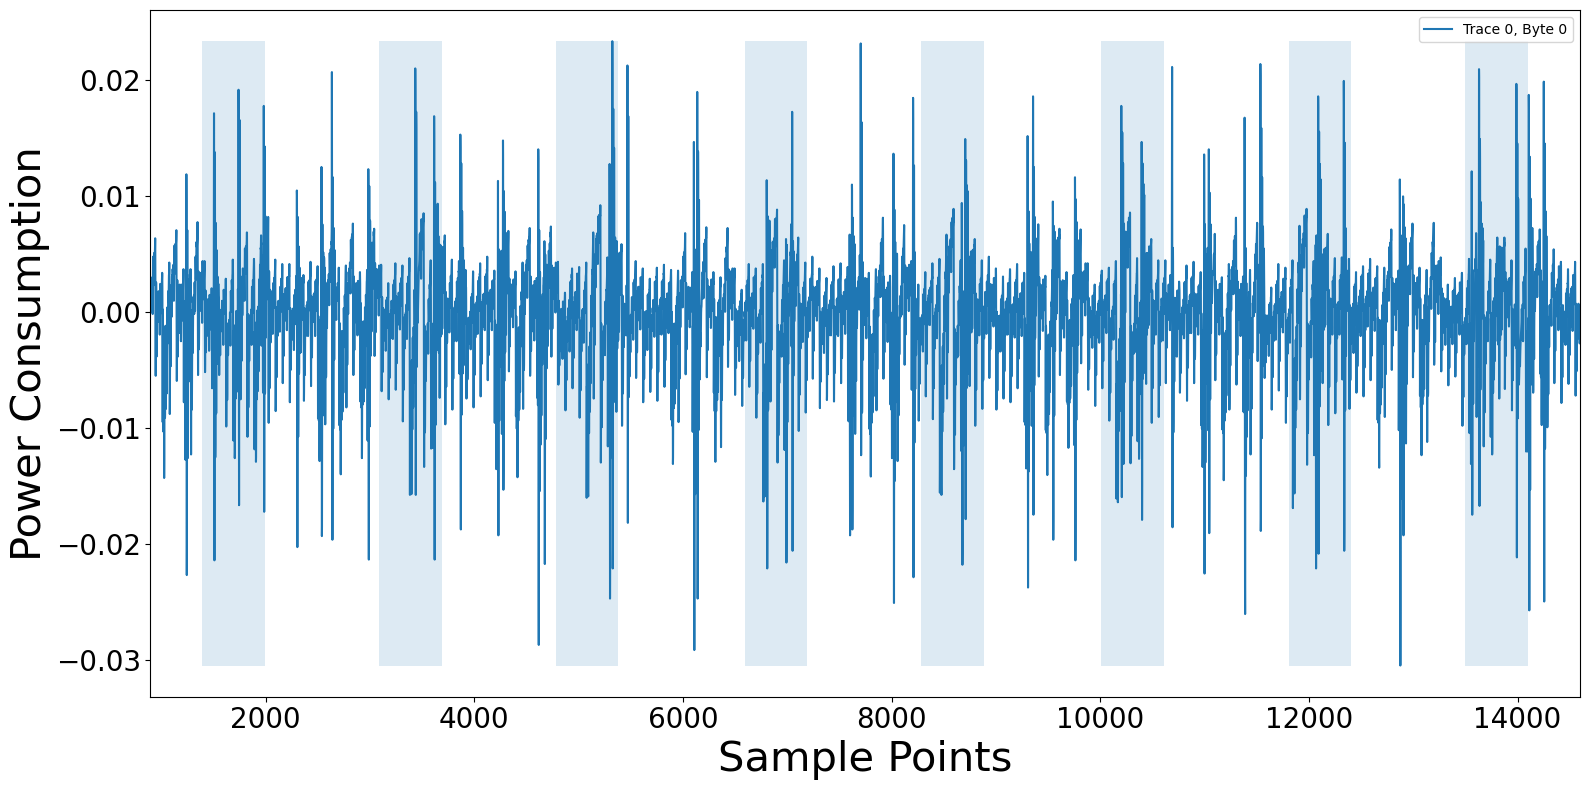

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 假设已定义：t（shape=(trace_num, L)），snr_idx（长度 ≥ 256），WIN，以及你要看的 trace_id, byte
trace_id   = 0
byte       = 0
WIN        = 300
extra_pre  = 500   # 在“第一个 POI - WIN”之前再扩 500 点
extra_post = 500   # 在“最后一个 POI + WIN”之后再扩 500 点

# 取出这一组 8 个 POI 的全局索引
poi_global = snr_idx[byte*8:(byte+1)*8]

# 计算 segment 的起止（全局索引）
first_poi = int(poi_global[0])
last_poi  = int(poi_global[-1])

seg_start = max(first_poi - WIN - extra_pre, 0)
seg_end   = min(last_poi + WIN + extra_post, t.shape[1])
segment_length = seg_end - seg_start

# 切出这段数据，并准备全局 x 轴索引
seg = t[trace_id, seg_start:seg_end]
x   = np.arange(seg_start, seg_end)

# 画图
plt.figure(figsize=(16, 8))
plt.plot(x, seg, color="C0", label=f"Trace {trace_id}, Byte {byte}")

# 高亮每个 POI ±WIN 区域，统一用同一颜色
for idx in poi_global:
    start_rect = idx - WIN
    plt.gca().add_patch(
        Rectangle(
            (start_rect, seg.min()),
            width=2*WIN+1,
            height=seg.max() - seg.min(),
            color="C0",
            alpha=0.15,
            lw=0
        )
    )

# 设置 x 轴范围为全局索引区间
plt.xlim(seg_start, seg_end)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
# plt.savefig('figure/trace_preprocess_split/poi_location.png', dpi=200, bbox_inches='tight')
plt.show()


size of new_trace: (16000, 4808)
size of new_label: (16000,)


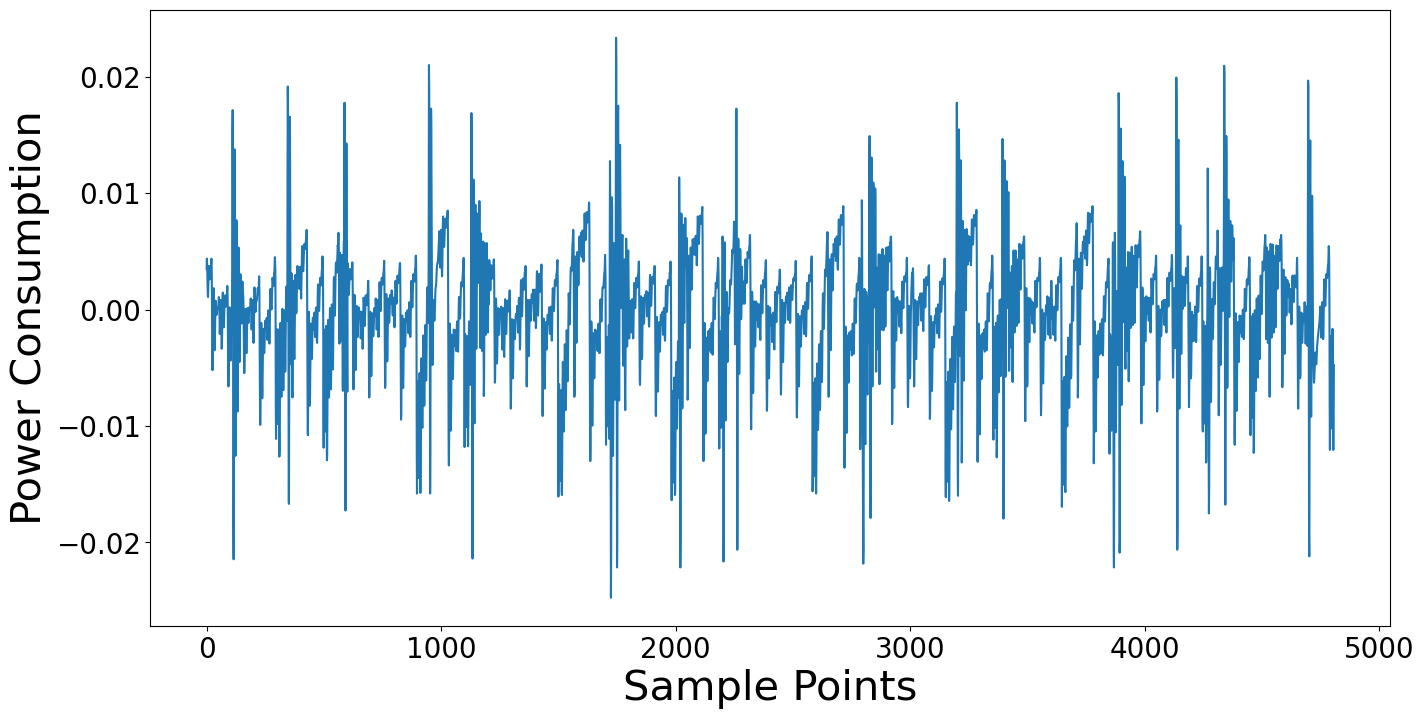

In [13]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)

print('size of new_trace:', X_flat.shape)
print('size of new_label:', Y_flat.shape)
plt.plot(X_flat[0])

# plt.savefig('figure/trace_preprocess_split/poi_result_of_new_single_trace.png', dpi=200, bbox_inches='tight')


size of new_trace: (16000, 4808)
size of new_label: (16000,)


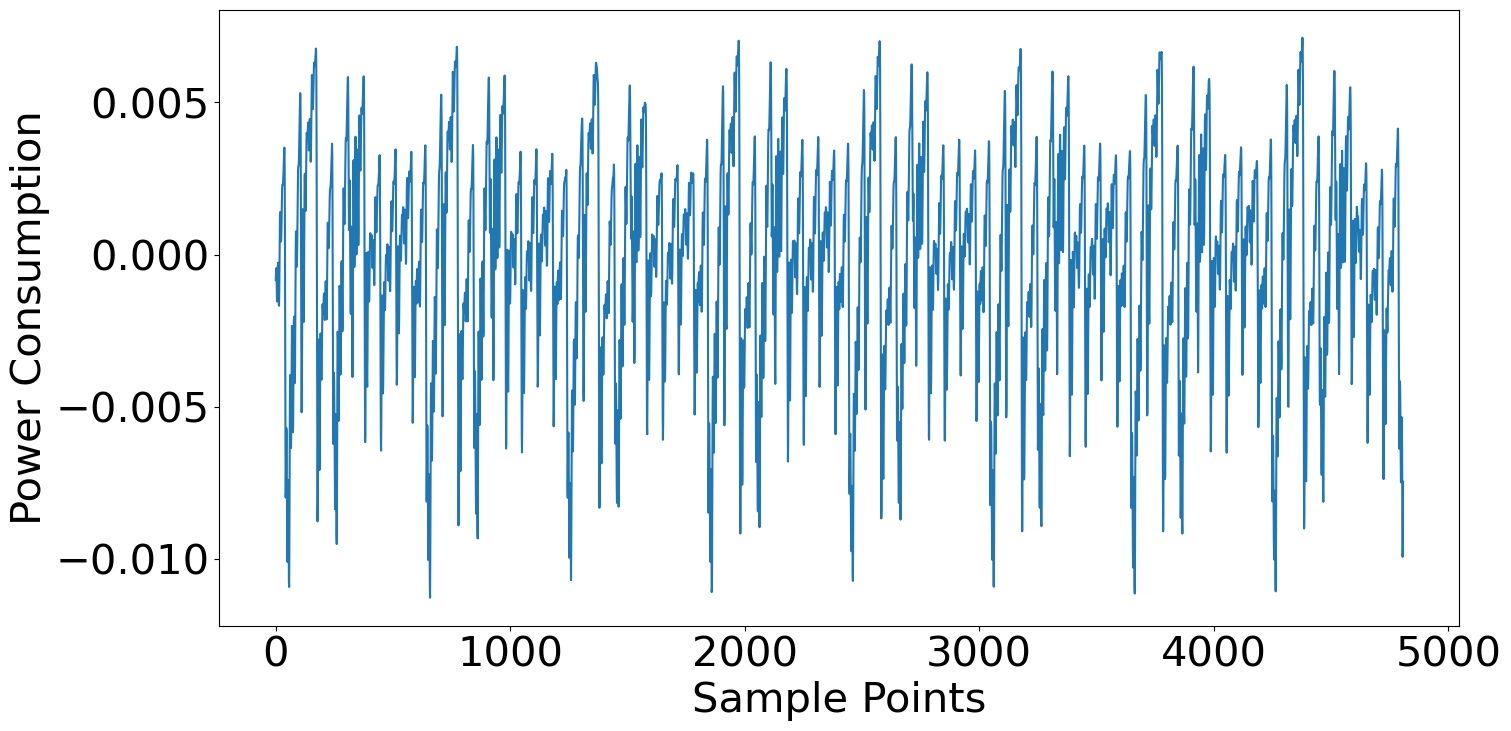

In [14]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=30)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=30)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)

print('size of new_trace:', X_flat.shape)
print('size of new_label:', Y_flat.shape)
plt.plot(np.mean(X_flat, axis=0))

# plt.savefig('figure/trace_preprocess_org/result_of_new__mean_trace.png', dpi=200, bbox_inches='tight')

In [15]:
poi = '_poi' # _poi or _segment
oscilloscope = "picoscope" # chipwhisperer or picoscope
trace_path = f'traces_attack/{trace_num}_3/traces_unfixed_message_{trace_num}_{oscilloscope}_{platform}_{opt}_{algo}{poi}_{order}'

if not os.path.exists(trace_path):
    os.makedirs(trace_path)
    print(f"已創建目錄: {trace_path}")


np.save(f'{trace_path}/trace.npy', X_flat)
np.save(f'{trace_path}/label.npy', Y_flat)

print('done')

已創建目錄: traces_attack/500_3/traces_unfixed_message_500_picoscope_CW308_STM32F4_o3_PQClean_poi_4
done
